# 09 - Build CJEU → EC Network & First Analysis

This notebook builds a bipartite directed network between CJEU documents and EC antitrust cases,
and performs a focused first analysis using only the most interpretable metrics for this network type.

**Input:** `data/processed/cjeu_ec_case_matches.csv`

**Output:**
- `data/processed/network/cjeu_ec_nodes.csv`
- `data/processed/network/cjeu_ec_edges.csv`
- `data/processed/network/cjeu_ec_network.graphml`
- `data/processed/network/cjeu_ec_node_metrics.csv`

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/processed")
INPUT_PATH = DATA_DIR / "cjeu_ec_case_matches.csv"

OUT_DIR           = DATA_DIR / "network"
NODES_PATH        = OUT_DIR / "cjeu_ec_nodes.csv"
EDGES_PATH        = OUT_DIR / "cjeu_ec_edges.csv"
GRAPHML_PATH      = OUT_DIR / "cjeu_ec_network.graphml"
NODE_METRICS_PATH = OUT_DIR / "cjeu_ec_node_metrics.csv"

# Match-strength ordering (higher index = stronger)
STRENGTH_ORDER = {"weak": 0, "medium": 1, "strong": 2}

print("Configuration loaded.")

Configuration loaded.


## 2. Load CSV

In [2]:
df = pd.read_csv(INPUT_PATH, dtype=str).fillna("")

print(f"Rows loaded : {len(df):,}")
print(f"Columns     : {list(df.columns)}")
df.head(3)

Rows loaded : 666
Columns     : ['cjeu_celex_id', 'cjeu_cellar_id', 'cjeu_title', 'cjeu_document_date', 'ec_case_number', 'ec_case_title', 'ec_celex_no', 'matched_pattern', 'matched_text', 'match_strength', 'match_context', 'document_source_url', 'document_format', 'processing_status']


,cjeu_celex_id,cjeu_cellar_id,cjeu_title,cjeu_document_date,ec_case_number,ec_case_title,ec_celex_no,matched_pattern,matched_text,match_strength,match_context,document_source_url,document_format,processing_status
0,61999TJ0219,c771ddef-393a-48fb-9fbd-a07f18f4b592,,2003-12-17,IV/32318,LONDON EUROPEAN-SABENA,31988D0589,(?<![A-Za-z0-9])(?:AT|IV|COMP)[\s./\-]*3[\s./\...,IV/32.318,medium,"lation to other markets related to air travel,...",https://publications.europa.eu/resource/celex/...,html_eng,matched
1,61999TJ0219,c771ddef-393a-48fb-9fbd-a07f18f4b592,,2003-12-17,IV/32659,IATA Passenger Agency Programme,31991D0480,(?<![A-Za-z0-9])(?:AT|IV|COMP)[\s./\-]*3[\s./\...,IV/32.659,medium,states that it has classified air travel agenc...,https://publications.europa.eu/resource/celex/...,html_eng,matched
2,62002TJ0038,b6ccae39-9aa5-4253-953a-22b37892e1ff,,2005-10-25,AT.35814,Extra d'alliage,,(?<![A-Za-z0-9])(?:AT|IV|COMP)[\s./\-]*3[\s./\...,IV/35.814,medium,the present case to an undertaking which did ...,https://publications.europa.eu/resource/celex/...,html_eng,matched


## 3. Filter: Only Real Matches

In [3]:
# Keep only rows with processing_status == "matched"
matched = df[df["processing_status"] == "matched"].copy()

# Drop rows with empty CJEU or EC identifiers
matched = matched[
    matched["cjeu_celex_id"].str.strip().ne("") &
    matched["ec_case_number"].str.strip().ne("")
].copy()

print(f"Rows after filtering: {len(matched):,}")

Rows after filtering: 666


## 4. Deduplicate to One Edge per CJEU-EC Pair

In [4]:
def best_strength(strengths: pd.Series) -> str:
    """Return the strongest match_strength value in a group."""
    ranked = strengths.map(lambda s: STRENGTH_ORDER.get(s, -1))
    best_idx = ranked.idxmax()
    return strengths.loc[best_idx]


edges_raw = (
    matched
    .groupby(["cjeu_celex_id", "ec_case_number"], sort=False)
    .agg(
        match_count           = ("match_strength", "count"),
        best_match_strength   = ("match_strength", best_strength),
        all_match_strengths   = ("match_strength", lambda s: "|".join(s.unique())),
        example_match_context = ("match_context", "first"),
    )
    .reset_index()
)

print(f"Unique CJEU-EC pairs (edges): {len(edges_raw):,}")
edges_raw.head(3)

Unique CJEU-EC pairs (edges): 666


,cjeu_celex_id,ec_case_number,match_count,best_match_strength,all_match_strengths,example_match_context
0,61999TJ0219,IV/32318,1,medium,medium,"lation to other markets related to air travel,..."
1,61999TJ0219,IV/32659,1,medium,medium,states that it has classified air travel agenc...
2,62002TJ0038,AT.35814,1,medium,medium,the present case to an undertaking which did ...


## 5. Build Node Tables

In [5]:
# ── A. CJEU nodes ──────────────────────────────────────────────────────────────
cjeu_meta = (
    matched[["cjeu_celex_id", "cjeu_title", "cjeu_document_date"]]
    .drop_duplicates(subset="cjeu_celex_id")
    .copy()
)

cjeu_nodes = pd.DataFrame({
    "node_id"  : "cjeu:" + cjeu_meta["cjeu_celex_id"],
    "node_type": "cjeu",
    "label"    : cjeu_meta["cjeu_title"].values,
    "celex_id" : cjeu_meta["cjeu_celex_id"].values,
    "date"     : cjeu_meta["cjeu_document_date"].values,
})

print(f"CJEU nodes: {len(cjeu_nodes):,}")
cjeu_nodes.head(3)

CJEU nodes: 383


,node_id,node_type,label,celex_id,date
0,cjeu:61999TJ0219,cjeu,,61999TJ0219,2003-12-17
2,cjeu:62002TJ0038,cjeu,,62002TJ0038,2005-10-25
10,cjeu:61982CJ0007,cjeu,,61982CJ0007,1983-03-02


In [6]:
# ── B. EC nodes ────────────────────────────────────────────────────────────────
ec_meta = (
    matched[["ec_case_number", "ec_case_title", "ec_celex_no"]]
    .drop_duplicates(subset="ec_case_number")
    .copy()
)

ec_nodes = pd.DataFrame({
    "node_id"    : "ec:" + ec_meta["ec_case_number"],
    "node_type"  : "ec",
    "label"      : ec_meta["ec_case_title"].values,
    "case_number": ec_meta["ec_case_number"].values,
    "celex_no"   : ec_meta["ec_celex_no"].values,
})

print(f"EC nodes: {len(ec_nodes):,}")
ec_nodes.head(3)

EC nodes: 210


,node_id,node_type,label,case_number,celex_no
0,ec:IV/32318,ec,LONDON EUROPEAN-SABENA,IV/32318,31988D0589
1,ec:IV/32659,ec,IATA Passenger Agency Programme,IV/32659,31991D0480
2,ec:AT.35814,ec,Extra d'alliage,AT.35814,


## 6. Build Edge Table

In [7]:
edges = edges_raw.copy()
edges.insert(0, "source", "cjeu:" + edges["cjeu_celex_id"])
edges.insert(1, "target", "ec:"   + edges["ec_case_number"])

print(f"Edges: {len(edges):,}")
edges.head(3)

Edges: 666


,source,target,cjeu_celex_id,ec_case_number,match_count,best_match_strength,all_match_strengths,example_match_context
0,cjeu:61999TJ0219,ec:IV/32318,61999TJ0219,IV/32318,1,medium,medium,"lation to other markets related to air travel,..."
1,cjeu:61999TJ0219,ec:IV/32659,61999TJ0219,IV/32659,1,medium,medium,states that it has classified air travel agenc...
2,cjeu:62002TJ0038,ec:AT.35814,62002TJ0038,AT.35814,1,medium,medium,the present case to an undertaking which did ...


## 7. Build NetworkX Bipartite Graph

In [8]:
G = nx.DiGraph()

# Add CJEU nodes
for _, row in cjeu_nodes.iterrows():
    G.add_node(
        row["node_id"],
        node_type="cjeu",
        label=row["label"],
        celex_id=row["celex_id"],
        date=row["date"],
        bipartite=0,
    )

# Add EC nodes
for _, row in ec_nodes.iterrows():
    G.add_node(
        row["node_id"],
        node_type="ec",
        label=row["label"],
        case_number=row["case_number"],
        celex_no=row["celex_no"],
        bipartite=1,
    )

# Add edges
for _, row in edges.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        match_count=int(row["match_count"]),
        best_match_strength=row["best_match_strength"],
        all_match_strengths=row["all_match_strengths"],
        example_match_context=str(row["example_match_context"])[:300],
    )

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Graph: 593 nodes, 666 edges


## 8. Basic Statistics

In [9]:
print(f"CJEU nodes : {len(cjeu_nodes):,}")
print(f"EC nodes   : {len(ec_nodes):,}")
print(f"Edges      : {len(edges):,}")

CJEU nodes : 383
EC nodes   : 210
Edges      : 666


## 9. Visualisation (Top 50 Nodes)

A quick visual impression of the network using the 25 most-cited EC cases and the 25 most-citing CJEU documents.

Subgraph: 50 nodes, 67 edges


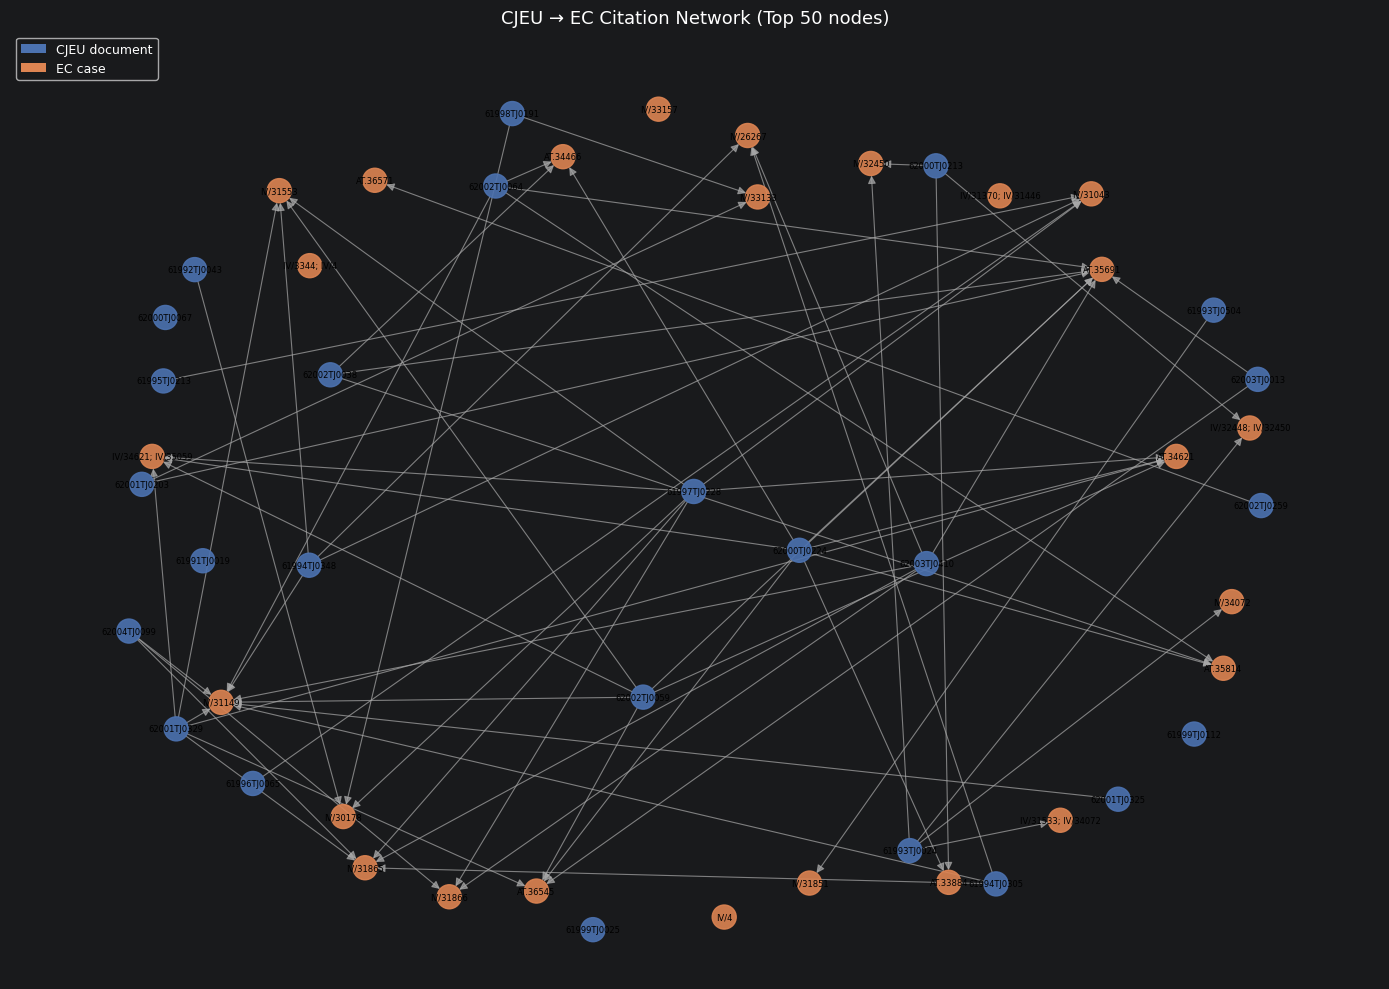

In [10]:
from matplotlib.patches import Patch

# Pre-compute degree series for subgraph selection
in_deg_series = pd.Series(
    {n: d for n, d in G.in_degree() if G.nodes[n]["node_type"] == "ec"},
    name="in_degree",
).sort_values(ascending=False)

out_deg_series = pd.Series(
    {n: d for n, d in G.out_degree() if G.nodes[n]["node_type"] == "cjeu"},
    name="out_degree",
).sort_values(ascending=False)

# Select the 25 most-cited EC nodes and 25 most-citing CJEU nodes
top_ec_ids   = in_deg_series.head(25).index.tolist()
top_cjeu_ids = out_deg_series.head(25).index.tolist()

sub_nodes = set(top_ec_ids) | set(top_cjeu_ids)
H = G.subgraph(sub_nodes).copy()

print(f"Subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

# Node colours
color_map = [
    "#4C72B0" if H.nodes[n]["node_type"] == "cjeu" else "#DD8452"
    for n in H.nodes()
]

# Short labels
labels = {}
for n in H.nodes():
    attrs = H.nodes[n]
    if attrs["node_type"] == "cjeu":
        labels[n] = attrs.get("celex_id", n)
    else:
        labels[n] = attrs.get("case_number", n)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(H, seed=42, k=1.5)

nx.draw_networkx_nodes(H, pos, node_color=color_map, node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H, pos, edge_color="#aaaaaa", arrows=True,
                       arrowsize=12, width=0.8, alpha=0.7, ax=ax)
nx.draw_networkx_labels(H, pos, labels=labels, font_size=6, ax=ax)

legend_elements = [
    Patch(facecolor="#4C72B0", label="CJEU document"),
    Patch(facecolor="#DD8452", label="EC case"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("CJEU → EC Citation Network (Top 50 nodes)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 10. Network Analysis

The sections below compute the core node metrics for this bipartite directed graph.
Only the most interpretable metrics for a CJEU → EC citation network are included:
**in-degree**, **out-degree**, and **PageRank**.

> **Note on edge attributes** (`match_count`, `best_match_strength`):
> These describe how well a CJEU document matches an EC case (number of matching passages,
> strongest match type). They are not centrality measures and are not used in the computations
> below, but remain available for filtering or weighting in future analyses.

### 10.1 In-Degree and Out-Degree

**What it measures:**
- **In-degree** = number of incoming edges → how often a node is *cited*.
- **Out-degree** = number of outgoing edges → how many citations a node *makes*.

**Why it matters for this citation network:**
In-degree is the simplest and most direct proxy for the importance of an EC case:
the more CJEU documents cite it, the more influential it is.
Out-degree shows which CJEU documents are the most prolific citers of EC antitrust cases.

**Most meaningful for:**
- In-degree → **EC nodes** (which cases are most cited by CJEU)
- Out-degree → **CJEU nodes** (which documents cite the most EC cases)

In [11]:
# Compute in- and out-degree for every node
in_degree_all  = dict(G.in_degree())
out_degree_all = dict(G.out_degree())

# ── Top cited EC cases (by in-degree) ─────────────────────────────────────────
ec_in = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(in_degree=lambda df: df.index.map(in_degree_all))
    .sort_values("in_degree", ascending=False)
)

print("Top 20 most cited EC cases (in-degree):")
display(ec_in.head(20))

Top 20 most cited EC cases (in-degree):


,case_number,label,in_degree
node_id,,,
ec:IV/31149,IV/31149,POLYPROPYLENE,41
ec:AT.35691,AT.35691,Pre-insulated pipe cartel,25
ec:IV/31865,IV/31865,PVC,19
ec:IV/4,IV/4,GRUNDIG,19
ec:IV/3344; IV/4,IV/3344; IV/4,Grundig-Consten,19
ec:IV/31553,IV/31553,Welded Steel Mesh,18
ec:AT.34466,AT.34466,Greek Ferries,16
ec:AT.36545,AT.36545,PO/Amino acids,14
ec:IV/33133,IV/33133,Soda-ash - ICI,12


In [12]:
# ── Top citing CJEU documents (by out-degree) ─────────────────────────────────
cjeu_out = (
    cjeu_nodes.set_index("node_id")[["celex_id", "label", "date"]]
    .assign(out_degree=lambda df: df.index.map(out_degree_all))
    .sort_values("out_degree", ascending=False)
)

print("Top 20 most citing CJEU documents (out-degree):")
display(cjeu_out.head(20))

Top 20 most citing CJEU documents (out-degree):


,celex_id,label,date,out_degree
node_id,,,,
cjeu:61997TJ0228,61997TJ0228,,1999-10-07,11
cjeu:61991TJ0019,61991TJ0019,,1992-02-27,11
cjeu:61998TJ0191,61998TJ0191,,2003-09-30,11
cjeu:61995TJ0213,61995TJ0213,,1997-10-22,8
cjeu:61993TJ0024,61993TJ0024,,1996-10-08,8
cjeu:62000TJ0224,62000TJ0224,,2003-07-09,8
cjeu:62002TJ0038,62002TJ0038,,2005-10-25,8
cjeu:61994TJ0348,61994TJ0348,,1998-05-14,7
cjeu:62001TJ0325,62001TJ0325,,2005-09-15,7


### 10.2 PageRank

**What it measures:**
PageRank assigns a score to each node based on the number and quality of incoming links.
A node receives a higher score if it is cited by nodes that are themselves highly cited.

**Why it matters for this citation network:**
Unlike raw in-degree, PageRank accounts for the *prestige* of the citing document.
An EC case cited by many influential CJEU judgments will rank higher than one cited
by less prominent documents.

**Most meaningful for:** **EC nodes** — identifies the most *prestigious* EC cases in the network.

> **Bipartite note:** PageRank is well-defined on directed graphs regardless of bipartiteness.
> CJEU nodes also receive a score, but the primary interpretation is for EC nodes.

In [13]:
pagerank = nx.pagerank(G, alpha=0.85)

# Top EC cases by PageRank
ec_pr = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree=lambda df: df.index.map(in_degree_all),
        pagerank =lambda df: df.index.map(pagerank),
    )
    .sort_values("pagerank", ascending=False)
)

print("Top 20 EC cases by PageRank:")
display(ec_pr.head(20))

Top 20 EC cases by PageRank:


,case_number,label,in_degree,pagerank
node_id,,,,
ec:IV/31149,IV/31149,POLYPROPYLENE,41,0.027854
ec:AT.35691,AT.35691,Pre-insulated pipe cartel,25,0.014576
ec:IV/31553,IV/31553,Welded Steel Mesh,18,0.013858
ec:AT.34466,AT.34466,Greek Ferries,16,0.011426
ec:IV/31865,IV/31865,PVC,19,0.009643
ec:IV/33133,IV/33133,Soda-ash - ICI,12,0.009273
ec:IV/3344; IV/4,IV/3344; IV/4,Grundig-Consten,19,0.008957
ec:IV/4,IV/4,GRUNDIG,19,0.008957
ec:IV/26267,IV/26267,Matières colorantes,11,0.008380


---
## 11. Node-Level Metric Summary Table

All three core metrics are combined into a single node-level table for easy inspection and export.
Each row represents one node (CJEU document or EC case) with its `in_degree`, `out_degree`, and `pagerank`.

In [14]:
all_nodes = pd.concat([cjeu_nodes, ec_nodes], ignore_index=True)

node_metrics = all_nodes[["node_id", "node_type", "label"]].copy()

node_metrics["in_degree"]  = node_metrics["node_id"].map(in_degree_all)
node_metrics["out_degree"] = node_metrics["node_id"].map(out_degree_all)
node_metrics["pagerank"]   = node_metrics["node_id"].map(pagerank)

print(f"Node metrics table: {len(node_metrics):,} rows")
display(node_metrics.head(20))

Node metrics table: 593 rows


,node_id,node_type,label,in_degree,out_degree,pagerank
0,cjeu:61999TJ0219,cjeu,,0,2,0.001088
1,cjeu:62002TJ0038,cjeu,,0,8,0.001088
2,cjeu:61982CJ0007,cjeu,,0,1,0.001088
3,cjeu:62001TJ0057,cjeu,,0,4,0.001088
4,cjeu:61989TJ0068,cjeu,,0,1,0.001088
5,cjeu:62000CO0241,cjeu,,0,1,0.001088
6,cjeu:61997TJ0228,cjeu,,0,11,0.001088
7,cjeu:61989TJ0030,cjeu,,0,1,0.001088
8,cjeu:62001TJ0151,cjeu,,0,1,0.001088
9,cjeu:61998TJ0191,cjeu,,0,11,0.001088


---
## 12. Summary Tables

### 12A. Top Cited EC Cases

Ranked by **in-degree** (raw citation count), also showing **PageRank** (prestige-weighted score).
These are the EC antitrust cases most frequently referenced by CJEU documents.

In [15]:
top_ec_cited = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree=lambda df: df.index.map(in_degree_all),
        pagerank =lambda df: df.index.map(pagerank),
    )
    .sort_values(["in_degree", "pagerank"], ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most cited EC cases (ranked by in-degree, then PageRank):")
display(top_ec_cited.head(30))

Top 30 most cited EC cases (ranked by in-degree, then PageRank):


,case_number,label,in_degree,pagerank
0,IV/31149,POLYPROPYLENE,41,0.027854
1,AT.35691,Pre-insulated pipe cartel,25,0.014576
2,IV/31865,PVC,19,0.009643
3,IV/3344; IV/4,Grundig-Consten,19,0.008957
4,IV/4,GRUNDIG,19,0.008957
5,IV/31553,Welded Steel Mesh,18,0.013858
6,AT.34466,Greek Ferries,16,0.011426
7,AT.36545,PO/Amino acids,14,0.007795
8,IV/33133,Soda-ash - ICI,12,0.009273
9,IV/26267,Matières colorantes,11,0.008380


### 12B. Top Citing CJEU Documents

Ranked by **out-degree** (number of distinct EC cases cited).
These are the CJEU documents that draw most heavily on EC antitrust precedents.

In [16]:
top_cjeu_citing = (
    cjeu_nodes.set_index("node_id")[["celex_id", "label", "date"]]
    .assign(
        out_degree=lambda df: df.index.map(out_degree_all),
    )
    .sort_values("out_degree", ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most citing CJEU documents (ranked by out-degree):")
display(top_cjeu_citing.head(30))

Top 30 most citing CJEU documents (ranked by out-degree):


,celex_id,label,date,out_degree
0,61997TJ0228,,1999-10-07,11
1,61991TJ0019,,1992-02-27,11
2,61998TJ0191,,2003-09-30,11
3,61995TJ0213,,1997-10-22,8
4,61993TJ0024,,1996-10-08,8
5,62000TJ0224,,2003-07-09,8
6,62002TJ0038,,2005-10-25,8
7,61994TJ0348,,1998-05-14,7
8,62001TJ0325,,2005-09-15,7
9,62002TJ0059,,2006-09-27,7


---
## 13. Export

In [17]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Node and edge tables
all_nodes.to_csv(NODES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(all_nodes):,} nodes to: {NODES_PATH}")

edges.to_csv(EDGES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(edges):,} edges to: {EDGES_PATH}")

# GraphML
nx.write_graphml(G, str(GRAPHML_PATH))
print(f"Saved GraphML to: {GRAPHML_PATH}")

# Node metrics
node_metrics.to_csv(NODE_METRICS_PATH, index=False, encoding="utf-8")
print(f"Saved node metrics to: {NODE_METRICS_PATH}")


Saved 593 nodes to: data\processed\network\cjeu_ec_nodes.csv
Saved 666 edges to: data\processed\network\cjeu_ec_edges.csv
Saved GraphML to: data\processed\network\cjeu_ec_network.graphml
Saved node metrics to: data\processed\network\cjeu_ec_node_metrics.csv
